In [ ]:
# HipMRI 2D Prostate Segmentation with U-Net (PyTorch)
# =====================================================
# Author: Your Name / Student ID
# COMP3710 - Pattern Analysis 2025
#
# This notebook implements Task 2 from Section 1.3 of the COMP3710 report:
# "Segment the HipMRI Study on Prostate Cancer using 2D U-Net with a minimum Dice coefficient of 0.75 on the test set (prostate label)."

# --- Imports and Config ---
import os, glob, nibabel as nib, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


In [ ]:

# --- Paths ---
data_root = r"C:\\Users\\User\\Desktop\\Final project comp3710\\keras_slices_data"
img_train_dir = os.path.join(data_root, 'keras_slices_train')
seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')


In [ ]:

# --- Dataset Class ---
class HipMRIDataset(Dataset):
    def __init__(self, img_dir, seg_dir, transform=None):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True))
        self.seg_paths = sorted(glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = nib.load(self.img_paths[idx]).get_fdata().astype(np.float32)
        seg = nib.load(self.seg_paths[idx]).get_fdata().astype(np.int64)

        # Normalize image (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Add channel dim
        img = np.expand_dims(img, axis=0)
        
        # Convert to tensors
        img = torch.from_numpy(img).float()
        seg = torch.from_numpy(seg).long()

        if self.transform:
            img = self.transform(img)

        return img, seg





In [ ]:

# --- Dataset Class (paired paths + binary mapping) ---
from pathlib import Path

DEF_PROSTATE_LABEL = 5  # <-- CHANGE THIS to the correct label id printed above

def _stem_key(p: Path):
    s = p.stem
    return s[4:] if s.startswith('seg_') else s  # drop leading 'seg_' so names align

class HipMRIDataset(Dataset):
    def __init__(self, img_dir, seg_dir, prostate_label=DEF_PROSTATE_LABEL, binary=True, transform=None):
        img_paths = sorted([Path(p) for p in glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True)])
        seg_paths = sorted([Path(p) for p in glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True)])
        img_map = { _stem_key(p): p for p in img_paths }
        seg_map = { _stem_key(p): p for p in seg_paths }
        common = sorted(set(img_map.keys()) & set(seg_map.keys()))
        if len(common) == 0:
            raise RuntimeError("No matching image/seg pairs found. Check directory paths and names.")
        if len(img_paths) != len(seg_paths):
            print(f"[WARN] images={len(img_paths)} segs={len(seg_paths)}; using matched pairs={len(common)}")
        self.pairs = [(img_map[k], seg_map[k]) for k in common]
        self.prostate_label = prostate_label
        self.binary = binary
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, seg_path = self.pairs[idx]
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        seg = nib.load(str(seg_path)).get_fdata()
        seg = np.rint(seg).astype(np.int64)  # ensure integer mask

        # normalise image (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # binary mapping: prostate vs background
        if self.binary:
            seg = (seg == self.prostate_label).astype(np.int64)
        else:
            # optional: remap arbitrary labels to contiguous 0..K-1
            uniq = np.unique(seg)
            remap = {v:i for i,v in enumerate(sorted(uniq))}
            seg = np.vectorize(remap.get)(seg).astype(np.int64)

        # to tensors
        img = torch.from_numpy(img[None, ...]).float()  # (1,H,W)
        seg = torch.from_numpy(seg).long()              # (H,W)

        if self.transform:
            img = self.transform(img)
        return img, seg



In [ ]:


# --- Model: Simple 2D U-Net ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet2D(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.inc = DoubleConv(1, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv1(x)
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)
        logits = self.outc(x)
        return logits

'''# --- Dice Metric ---
def dice_coeff(pred, target, eps=1e-6):
    pred = torch.softmax(pred, dim=1)
    pred_classes = torch.argmax(pred, dim=1)
    pred_flat = pred_classes.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    intersection = (pred_flat * target_flat).sum().float()
    union = pred_flat.sum() + target_flat.sum()
    dice = (2. * intersection + eps) / (union + eps)
    return dice.item()
'''
# --- Dice Metric (binary foreground) ---
def dice_coeff_binary(logits, target, eps=1e-6):
    # logits: (N,2,H,W) ; target: (N,H,W) in {0,1}
    probs = torch.softmax(logits, dim=1)[:, 1]  # foreground prob
    pred = (probs > 0.5).long()
    target = target.long()
    intersection = (pred & target).sum(dim=(1,2)).float()
    union = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2*intersection + eps) / (union + eps)).mean().item()



In [ ]:

# --- Prepare Datasets ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

# PREVIOUS, NOT USED

In [ ]:
# --- Prepare Datasets / Loaders ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir,
                              prostate_label=DEF_PROSTATE_LABEL, binary=True)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)



In [ ]:


# --- Initialize Model, Loss, Optimizer ---
model = UNet2D(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)



In [ ]:
import os, glob, nibabel as nib, numpy as np

seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')  # already defined earlier
sample_paths = sorted(glob.glob(os.path.join(seg_train_dir, '**', '*.nii'), recursive=True))[:10]
uniqs = set()
for p in sample_paths:
    a = nib.load(p).get_fdata()
    uniqs.update(np.unique(np.rint(a)).astype(int).tolist())
print('[DEBUG] Unique labels seen in first 10 masks:', sorted(uniqs))



In [ ]:

# --- Training Loop (Simple) ---
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, segs in train_loader:
        imgs, segs = imgs.to(device), segs.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, segs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

# --- Save Model ---
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/unet2d_hipmri.pth')

# --- Visualize Example Prediction ---
model.eval()
with torch.no_grad():
    sample_img, sample_seg = train_dataset[0]
    pred = model(sample_img.unsqueeze(0).to(device))
    pred_class = torch.argmax(pred, dim=1).cpu().squeeze()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title('Input MRI Slice')
plt.subplot(1,3,2)
plt.imshow(sample_seg, cmap='jet')
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(pred_class, cmap='jet')
plt.title('Predicted Segmentation')
plt.show()

print("Done. Model saved as models/unet2d_hipmri.pth")


In [ ]:
# HipMRI 2D Prostate Segmentation with U-Net (PyTorch)
# =====================================================
# COMP3710 Task 2 — segment prostate on HipMRI 2D slices with Dice >= 0.75 (test)
# This notebook is self-contained and includes:
#  - Robust image/mask pairing
#  - Binary mapping to prostate vs background
#  - Train/val/test loops with Dice metric
#  - Best-checkpoint saving and sample visualisation
#
# Notes:
#  - Keep your dataset OUTSIDE the repo. Point `data_root` to your local path.
#  - Run your separate `decompress_data.py` once to create .nii files from .nii.gz archives.

# --- 0. Imports & Config ---
import os, glob, numpy as np, nibabel as nib, math, time
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from typing import Tuple

# Set deterministic-ish behaviour (optional)
# torch.manual_seed(42)
# np.random.seed(42)

# If you ever need more explicit CUDA errors, uncomment this:
# import os; os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# --- 1. Paths (EDIT THIS TO YOUR MACHINE) ---
data_root = r"C:\\Users\\User\\Desktop\\Final project comp3710\\keras_slices_data"
img_train_dir = os.path.join(data_root, 'keras_slices_train')
seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')
img_val_dir   = os.path.join(data_root, 'keras_slices_validate')
seg_val_dir   = os.path.join(data_root, 'keras_slices_seg_validate')
img_test_dir  = os.path.join(data_root, 'keras_slices_test')
seg_test_dir  = os.path.join(data_root, 'keras_slices_seg_test')

# Sanity check exists (comment out if paths differ)
for p in [img_train_dir, seg_train_dir, img_val_dir, seg_val_dir, img_test_dir, seg_test_dir]:
    if not os.path.isdir(p):
        print('[WARN] Missing dir:', p)

# --- 2. Utilities ---
DEF_PROSTATE_LABEL = 3  # based on your debug: labels were [0,1,2,3] and prostate is 3

def _stem_key(p: Path) -> str:
    """Comparable key for pairing image/seg by filename (drop leading 'seg_' prefix)."""
    s = p.stem
    return s[4:] if s.startswith('seg_') else s

def scan_unique_labels(seg_dir: str, k: int = 10):
    pats = sorted(glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True))[:k]
    uniqs = set()
    for p in pats:
        a = nib.load(p).get_fdata()
        uniqs.update(np.unique(np.rint(a)).astype(int).tolist())
    print('[DEBUG] Unique label ids (first', k, 'masks):', sorted(list(uniqs)))

# Optional: run once to verify (commented by default)
# scan_unique_labels(seg_train_dir, k=10)

# --- 3. Dataset ---
class HipMRIDataset(Dataset):
    def __init__(self, img_dir: str, seg_dir: str, prostate_label: int = DEF_PROSTATE_LABEL,
                 binary: bool = True):
        img_paths = sorted([Path(p) for p in glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True)])
        seg_paths = sorted([Path(p) for p in glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True)])
        img_map = { _stem_key(p): p for p in img_paths }
        seg_map = { _stem_key(p): p for p in seg_paths }
        common = sorted(set(img_map.keys()) & set(seg_map.keys()))
        if len(common) == 0:
            raise RuntimeError('No matching image/seg pairs found. Check directory paths and names.')
        if len(img_paths) != len(seg_paths):
            print(f"[WARN] images={len(img_paths)} segs={len(seg_paths)}; using matched pairs={len(common)}")
        self.pairs = [(img_map[k], seg_map[k]) for k in common]
        self.prostate_label = prostate_label
        self.binary = binary

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, seg_path = self.pairs[idx]
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        seg = nib.load(str(seg_path)).get_fdata()
        seg = np.rint(seg).astype(np.int64)   # ensure integer mask

        # Normalise image (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Binary mapping: prostate vs background
        if self.binary:
            seg = (seg == self.prostate_label).astype(np.int64)  # {0,1}

        img_t = torch.from_numpy(img[None, ...]).float()  # (1,H,W)
        seg_t = torch.from_numpy(seg).long()              # (H,W)
        return img_t, seg_t

# --- 4. Model (U-Net 2D) ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, n_classes=2, base=64):
        super().__init__()
        self.inc   = DoubleConv(1, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base, base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))
        self.up1   = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv1 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up3   = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv3 = DoubleConv(base*2, base)
        self.outc  = nn.Conv2d(base, n_classes, 1)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x  = self.up1(x4)
        x  = torch.cat([x, x3], dim=1)
        x  = self.conv1(x)
        x  = self.up2(x)
        x  = torch.cat([x, x2], dim=1)
        x  = self.conv2(x)
        x  = self.up3(x)
        x  = torch.cat([x, x1], dim=1)
        x  = self.conv3(x)
        return self.outc(x)

# --- 5. Metrics ---
def dice_binary_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> float:
    """Binary Dice on foreground class. logits: (N,2,H,W), target: (N,H,W) in {0,1}."""
    probs = torch.softmax(logits, dim=1)[:, 1]   # foreground prob
    pred  = (probs > 0.5).long()
    target = target.long()
    intersection = (pred & target).sum(dim=(1,2)).float()
    union       = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2*intersection + eps) / (union + eps)).mean().item()

@torch.no_grad()
def evaluate_dice(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for imgs, segs in loader:
        imgs, segs = imgs.to(device), segs.to(device)
        logits = model(imgs)
        total += dice_binary_from_logits(logits, segs)
    return total / max(1, len(loader))

# --- 6. DataLoaders ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir, prostate_label=DEF_PROSTATE_LABEL, binary=True)
val_dataset   = HipMRIDataset(img_val_dir,   seg_val_dir,   prostate_label=DEF_PROSTATE_LABEL, binary=True)
test_dataset  = HipMRIDataset(img_test_dir,  seg_test_dir,  prostate_label=DEF_PROSTATE_LABEL, binary=True)

# On Windows keep num_workers=0 to avoid file handle issues
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} slices | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# --- 7. Train ---
model = UNet2D(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()            # targets in {0,1}
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
# Optional speed-up on CUDA
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

EPOCHS = 20
best_val_dice = -1.0
os.makedirs('models', exist_ok=True)
best_ckpt = 'models/unet2d_hipmri_best.pth'

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    for imgs, segs in train_loader:
        imgs, segs = imgs.to(device), segs.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, segs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_dice += dice_binary_from_logits(logits, segs)

    train_loss = running_loss / max(1, len(train_loader))
    train_dice = running_dice / max(1, len(train_loader))
    val_dice   = evaluate_dice(model, val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_ckpt)

    print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss {train_loss:.4f} | Train Dice {train_dice:.4f} | Val Dice {val_dice:.4f} | Best {best_val_dice:.4f}")

print('Training complete. Best Val Dice:', best_val_dice)

# --- 8. Test evaluation (load best) ---
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.to(device)

test_dice = evaluate_dice(model, test_loader)
print(f"TEST Dice (prostate): {test_dice:.4f}")

# --- 9. Visualisation of a few predictions ---
@torch.no_grad()
def show_samples(model, dataset, k=3):
    model.eval()
    plt.figure(figsize=(12, 4*k))
    for i in range(k):
        img, seg = dataset[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).cpu().squeeze()
        ax1 = plt.subplot(k, 3, 3*i+1); ax1.imshow(img.squeeze().numpy(), cmap='gray'); ax1.set_title('Input'); ax1.axis('off')
        ax2 = plt.subplot(k, 3, 3*i+2); ax2.imshow(seg.numpy(), cmap='jet');         ax2.set_title('GT (prostate=1)'); ax2.axis('off')
        ax3 = plt.subplot(k, 3, 3*i+3); ax3.imshow(pred.numpy(), cmap='jet');        ax3.set_title('Pred'); ax3.axis('off')
    plt.tight_layout(); plt.show()

show_samples(model, test_dataset, k=3)

print('Done. Best checkpoint saved to', best_ckpt)



In [ ]:
import os, glob
from pathlib import Path

def list_first(dirpath):
    paths = sorted(glob.glob(os.path.join(dirpath, '**', '*.nii'), recursive=True))
    return [Path(p).stem for p in paths], paths

img_stems, img_paths = list_first(img_train_dir)
seg_stems, seg_paths = list_first(seg_train_dir)

print("IMG .nii files:", len(img_paths))
print("SEG .nii files:", len(seg_paths))
print("\nFirst 8 IMG stems:", img_stems[:8])
print("First 8 SEG stems:", seg_stems[:8])




In [ ]:
# HipMRI 2D Prostate Segmentation with U-Net (PyTorch)
# =====================================================
# COMP3710 Task 2 — segment prostate on HipMRI 2D slices with Dice >= 0.75 (test)
# This notebook is self-contained and includes:
#  - Robust image/mask pairing
#  - Binary mapping to prostate vs background
#  - Train/val/test loops with Dice metric
#  - Best-checkpoint saving and sample visualisation
#
# Notes:
#  - Keep your dataset OUTSIDE the repo. Point `data_root` to your local path.
#  - Run your separate `decompress_data.py` once to create .nii files from .nii.gz archives.

# --- 0. Imports & Config ---
import os, glob, numpy as np, nibabel as nib, math, time
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from typing import Tuple

# Set deterministic-ish behaviour (optional)
# torch.manual_seed(42)
# np.random.seed(42)

# If you ever need more explicit CUDA errors, uncomment this:
# import os; os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# --- 1. Paths (EDIT THIS TO YOUR MACHINE) ---
data_root = r"C:\Users\User\Desktop\Final project comp3710\keras_slices_data"
img_train_dir = os.path.join(data_root, 'keras_slices_train')
seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')
img_val_dir   = os.path.join(data_root, 'keras_slices_validate')
seg_val_dir   = os.path.join(data_root, 'keras_slices_seg_validate')
img_test_dir  = os.path.join(data_root, 'keras_slices_test')
seg_test_dir  = os.path.join(data_root, 'keras_slices_seg_test')

# Sanity check exists (comment out if paths differ)
for p in [img_train_dir, seg_train_dir, img_val_dir, seg_val_dir, img_test_dir, seg_test_dir]:
    if not os.path.isdir(p):
        print('[WARN] Missing dir:', p)

# --- 2. Utilities ---
DEF_PROSTATE_LABEL = 3  # based on your debug: labels were [0,1,2,3] and prostate is 3

def _stem_key(p: Path) -> str:
    """Comparable key for pairing image/seg by filename (drop leading 'seg_' prefix)."""
    s = p.stem
    return s[4:] if s.startswith('seg_') else s

def scan_unique_labels(seg_dir: str, k: int = 10):
    pats = sorted(glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True))[:k]
    uniqs = set()
    for p in pats:
        a = nib.load(p).get_fdata()
        uniqs.update(np.unique(np.rint(a)).astype(int).tolist())
    print('[DEBUG] Unique label ids (first', k, 'masks):', sorted(list(uniqs)))

# Optional: run once to verify (commented by default)
# scan_unique_labels(seg_train_dir, k=10)

# --- 3. Dataset ---
class HipMRIDataset(Dataset):
    def __init__(self, img_dir: str, seg_dir: str, prostate_label: int = DEF_PROSTATE_LABEL,
                 binary: bool = True):
        img_paths = sorted([Path(p) for p in glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True)])
        seg_paths = sorted([Path(p) for p in glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True)])
        img_map = { _stem_key(p): p for p in img_paths }
        seg_map = { _stem_key(p): p for p in seg_paths }
        common = sorted(set(img_map.keys()) & set(seg_map.keys()))
        if len(common) == 0:
            raise RuntimeError('No matching image/seg pairs found. Check directory paths and names.')
        if len(img_paths) != len(seg_paths):
            print(f"[WARN] images={len(img_paths)} segs={len(seg_paths)}; using matched pairs={len(common)}")
        self.pairs = [(img_map[k], seg_map[k]) for k in common]
        self.prostate_label = prostate_label
        self.binary = binary

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, seg_path = self.pairs[idx]
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        seg = nib.load(str(seg_path)).get_fdata()
        seg = np.rint(seg).astype(np.int64)   # ensure integer mask

        # Normalise image (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Binary mapping: prostate vs background
        if self.binary:
            seg = (seg == self.prostate_label).astype(np.int64)  # {0,1}

        img_t = torch.from_numpy(img[None, ...]).float()  # (1,H,W)
        seg_t = torch.from_numpy(seg).long()              # (H,W)
        return img_t, seg_t

# --- 4. Model (U-Net 2D) ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, n_classes=2, base=64):
        super().__init__()
        self.inc   = DoubleConv(1, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base, base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))
        self.up1   = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv1 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up3   = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv3 = DoubleConv(base*2, base)
        self.outc  = nn.Conv2d(base, n_classes, 1)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x  = self.up1(x4)
        x  = torch.cat([x, x3], dim=1)
        x  = self.conv1(x)
        x  = self.up2(x)
        x  = torch.cat([x, x2], dim=1)
        x  = self.conv2(x)
        x  = self.up3(x)
        x  = torch.cat([x, x1], dim=1)
        x  = self.conv3(x)
        return self.outc(x)

# --- 5. Metrics ---
def dice_binary_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> float:
    """Binary Dice on foreground class. logits: (N,2,H,W), target: (N,H,W) in {0,1}."""
    probs = torch.softmax(logits, dim=1)[:, 1]   # foreground prob
    pred  = (probs > 0.5).long()
    target = target.long()
    intersection = (pred & target).sum(dim=(1,2)).float()
    union       = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2*intersection + eps) / (union + eps)).mean().item()

@torch.no_grad()
def evaluate_dice(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for imgs, segs in loader:
        imgs, segs = imgs.to(device), segs.to(device)
        logits = model(imgs)
        total += dice_binary_from_logits(logits, segs)
    return total / max(1, len(loader))

# --- 6. DataLoaders ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir, prostate_label=DEF_PROSTATE_LABEL, binary=True)
val_dataset   = HipMRIDataset(img_val_dir,   seg_val_dir,   prostate_label=DEF_PROSTATE_LABEL, binary=True)
test_dataset  = HipMRIDataset(img_test_dir,  seg_test_dir,  prostate_label=DEF_PROSTATE_LABEL, binary=True)

# On Windows keep num_workers=0 to avoid file handle issues
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} slices | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# --- 7. Train ---
model = UNet2D(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()            # targets in {0,1}
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
# Optional speed-up on CUDA
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

EPOCHS = 20
best_val_dice = -1.0
os.makedirs('models', exist_ok=True)
best_ckpt = 'models/unet2d_hipmri_best.pth'

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    for imgs, segs in train_loader:
        imgs, segs = imgs.to(device), segs.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, segs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_dice += dice_binary_from_logits(logits, segs)

    train_loss = running_loss / max(1, len(train_loader))
    train_dice = running_dice / max(1, len(train_loader))
    val_dice   = evaluate_dice(model, val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_ckpt)

    print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss {train_loss:.4f} | Train Dice {train_dice:.4f} | Val Dice {val_dice:.4f} | Best {best_val_dice:.4f}")

print('Training complete. Best Val Dice:', best_val_dice)

# --- 8. Test evaluation (load best) ---
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.to(device)

test_dice = evaluate_dice(model, test_loader)
print(f"TEST Dice (prostate): {test_dice:.4f}")

# --- 9. Visualisation of a few predictions ---
@torch.no_grad()
def show_samples(model, dataset, k=3):
    model.eval()
    plt.figure(figsize=(12, 4*k))
    for i in range(k):
        img, seg = dataset[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).cpu().squeeze()
        ax1 = plt.subplot(k, 3, 3*i+1); ax1.imshow(img.squeeze().numpy(), cmap='gray'); ax1.set_title('Input'); ax1.axis('off')
        ax2 = plt.subplot(k, 3, 3*i+2); ax2.imshow(seg.numpy(), cmap='jet');         ax2.set_title('GT (prostate=1)'); ax2.axis('off')
        ax3 = plt.subplot(k, 3, 3*i+3); ax3.imshow(pred.numpy(), cmap='jet');        ax3.set_title('Pred'); ax3.axis('off')
    plt.tight_layout(); plt.show()

show_samples(model, test_dataset, k=3)

print('Done. Best checkpoint saved to', best_ckpt)



In [ ]:
# HipMRI 2D Prostate Segmentation with U-Net (PyTorch)
# =====================================================
# COMP3710 Task 2 — segment prostate on HipMRI 2D slices with Dice >= 0.75 (test)
# This notebook is self-contained and includes:
#  - Robust image/mask pairing (handles 'case_' vs 'seg_' and regex on trailing slice id)
#  - Binary mapping to prostate vs background (DEF_PROSTATE_LABEL = 3)
#  - Train/val/test loops with Dice metric
#  - Best-checkpoint saving and sample visualisation
#
# Notes:
#  - Keep your dataset OUTSIDE the repo. Point `data_root` to your local path.
#  - Run your separate `decompress_data.py` once to create .nii files from .nii.gz archives.

# --- 0. Imports & Config ---
import os, glob, re, math, time
from pathlib import Path
from typing import Tuple

import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# If you ever need more explicit CUDA errors, uncomment this:
# import os; os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# --- 1. Paths (EDIT THIS TO YOUR MACHINE) ---
# Keep data outside your repo; do NOT commit datasets.
data_root = r"C:\Users\User\Desktop\Final project comp3710\keras_slices_data"
img_train_dir = os.path.join(data_root, 'keras_slices_train')
seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')
img_val_dir   = os.path.join(data_root, 'keras_slices_validate')
seg_val_dir   = os.path.join(data_root, 'keras_slices_seg_validate')
img_test_dir  = os.path.join(data_root, 'keras_slices_test')
seg_test_dir  = os.path.join(data_root, 'keras_slices_seg_test')

# Sanity check exists (warn only)
for p in [img_train_dir, seg_train_dir, img_val_dir, seg_val_dir, img_test_dir, seg_test_dir]:
    if not os.path.isdir(p):
        print('[WARN] Missing dir:', p)

# --- 2. Utilities ---
DEF_PROSTATE_LABEL = 3  # from your sanity check: labels were [0,1,2,3], prostate=3

# capture trailing pattern like: 004_week_0_slice_0
_TRAIL_PAT = re.compile(r'(\d+_week_\d+_slice_\d+)$')

def _slice_key_from_stem(stem: str) -> str:
    """
    Returns canonical key for pairing image/seg.
    Prefers trailing '004_week_0_slice_0' pattern; falls back to dropping 'case_'/'seg_' prefixes.
    """
    m = _TRAIL_PAT.search(stem)
    if m:
        return m.group(1)
    if stem.startswith('case_'):
        return stem[len('case_'):]
    if stem.startswith('seg_'):
        return stem[len('seg_'):]
    return stem

def _slice_key(p: Path) -> str:
    return _slice_key_from_stem(p.stem)

# Optional: list unique labels quickly
def scan_unique_labels(seg_dir: str, k: int = 10):
    pats = sorted(glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True))[:k]
    uniqs = set()
    for p in pats:
        a = nib.load(p).get_fdata()
        uniqs.update(np.unique(np.rint(a)).astype(int).tolist())
    print('[DEBUG] Unique label ids (first', k, 'masks):', sorted(list(uniqs)))

# --- 3. Dataset ---
class HipMRIDataset(Dataset):
    def __init__(self, img_dir: str, seg_dir: str, prostate_label: int = DEF_PROSTATE_LABEL,
                 binary: bool = True):
        img_paths = sorted([Path(p) for p in glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True)])
        seg_paths = sorted([Path(p) for p in glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True)])

        if len(img_paths) == 0 or len(seg_paths) == 0:
            raise RuntimeError(f"No .nii files found.\n  img_dir={img_dir}\n  seg_dir={seg_dir}")

        img_map = { _slice_key(p): p for p in img_paths }
        seg_map = { _slice_key(p): p for p in seg_paths }
        common = sorted(set(img_map.keys()) & set(seg_map.keys()))

        if len(common) == 0:
            img_only = sorted(list(set(img_map.keys()) - set(seg_map.keys())))[:10]
            seg_only = sorted(list(set(seg_map.keys()) - set(img_map.keys())))[:10]
            raise RuntimeError(
                "No matching image/seg pairs found.\n"
                f"  Only-in-IMG (first 10): {img_only}\n"
                f"  Only-in-SEG (first 10): {seg_only}\n"
            )

        if len(img_paths) != len(seg_paths):
            print(f"[WARN] images={len(img_paths)} segs={len(seg_paths)}; using matched pairs={len(common)}")

        self.pairs = [(img_map[k], seg_map[k]) for k in common]
        self.prostate_label = prostate_label
        self.binary = binary

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, seg_path = self.pairs[idx]
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        seg = nib.load(str(seg_path)).get_fdata()
        seg = np.rint(seg).astype(np.int64)   # ensure integer mask

        # Normalise image (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Binary mapping: prostate vs background
        if self.binary:
            seg = (seg == self.prostate_label).astype(np.int64)  # {0,1}

        img_t = torch.from_numpy(img[None, ...]).float()  # (1,H,W)
        seg_t = torch.from_numpy(seg).long()              # (H,W)
        return img_t, seg_t

# --- 4. Model (U-Net 2D) ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, n_classes=2, base=64):
        super().__init__()
        self.inc   = DoubleConv(1, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base,   base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))
        self.up1   = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv1 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up3   = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.conv3 = DoubleConv(base*2, base)
        self.outc  = nn.Conv2d(base, n_classes, 1)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x  = self.up1(x4)
        x  = torch.cat([x, x3], dim=1)
        x  = self.conv1(x)
        x  = self.up2(x)
        x  = torch.cat([x, x2], dim=1)
        x  = self.conv2(x)
        x  = self.up3(x)
        x  = torch.cat([x, x1], dim=1)
        x  = self.conv3(x)
        return self.outc(x)

# --- 5. Metrics ---
def dice_binary_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> float:
    """Binary Dice on foreground class. logits: (N,2,H,W), target: (N,H,W) in {0,1}."""
    probs = torch.softmax(logits, dim=1)[:, 1]   # foreground prob
    pred  = (probs > 0.5).long()
    target = target.long()
    intersection = (pred & target).sum(dim=(1,2)).float()
    union       = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2*intersection + eps) / (union + eps)).mean().item()

@torch.no_grad()
def evaluate_dice(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for imgs, segs in loader:
        imgs, segs = imgs.to(device), segs.to(device)
        logits = model(imgs)
        total += dice_binary_from_logits(logits, segs)
    return total / max(1, len(loader))

# --- 6. DataLoaders ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir, prostate_label=DEF_PROSTATE_LABEL, binary=True)
val_dataset   = HipMRIDataset(img_val_dir,   seg_val_dir,   prostate_label=DEF_PROSTATE_LABEL, binary=True)
test_dataset  = HipMRIDataset(img_test_dir,  seg_test_dir,  prostate_label=DEF_PROSTATE_LABEL, binary=True)

# On Windows keep num_workers=0 to avoid file handle issues
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
# Peek one sample
img0, seg0 = train_dataset[0]
print("Sample shapes:", tuple(img0.shape), tuple(seg0.shape), "labels min..max:", int(seg0.min()), int(seg0.max()))

# --- 7. Train ---
model = UNet2D(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()            # targets in {0,1}
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
# Optional speed-up on CUDA
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

EPOCHS = 20
best_val_dice = -1.0
os.makedirs('models', exist_ok=True)
best_ckpt = 'models/unet2d_hipmri_best.pth'

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    for imgs, segs in train_loader:
        imgs, segs = imgs.to(device), segs.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, segs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_dice += dice_binary_from_logits(logits, segs)

    train_loss = running_loss / max(1, len(train_loader))
    train_dice = running_dice / max(1, len(train_loader))
    val_dice   = evaluate_dice(model, val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_ckpt)

    print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss {train_loss:.4f} | Train Dice {train_dice:.4f} | Val Dice {val_dice:.4f} | Best {best_val_dice:.4f}")

print('Training complete. Best Val Dice:', best_val_dice)

# --- 8. Test evaluation (load best) ---
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.to(device)

test_dice = evaluate_dice(model, test_loader)
print(f"TEST Dice (prostate): {test_dice:.4f}")

# --- 9. Visualisation of a few predictions ---
@torch.no_grad()
def show_samples(model, dataset, k=3):
    model.eval()
    plt.figure(figsize=(12, 4*k))
    for i in range(k):
        img, seg = dataset[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).cpu().squeeze()
        ax1 = plt.subplot(k, 3, 3*i+1); ax1.imshow(img.squeeze().numpy(), cmap='gray'); ax1.set_title('Input'); ax1.axis('off')
        ax2 = plt.subplot(k, 3, 3*i+2); ax2.imshow(seg.numpy(), cmap='jet');         ax2.set_title('GT (prostate=1)'); ax2.axis('off')
        ax3 = plt.subplot(k, 3, 3*i+3); ax3.imshow(pred.numpy(), cmap='jet');        ax3.set_title('Pred'); ax3.axis('off')
    plt.tight_layout(); plt.show()

show_samples(model, test_dataset, k=3)

print('Done. Best checkpoint saved to', best_ckpt)



Using device: cuda
Train: 11460 | Val: 660 | Test: 540
Sample shapes: (1, 256, 128) (256, 128) labels min..max: 0 1


RuntimeError: stack expects each tensor to be equal size, but got [1, 256, 128] at entry 0 and [1, 256, 144] at entry 1

Using device: cuda
Train: 11460 | Val: 660 | Test: 540
Sample shapes: (1, 256, 256) (256, 256) labels min..max: 0 1
Epoch 001/20 | Train Loss 0.0232 | Train Dice 0.7561 | Val Dice 0.6676 | Best 0.6676
Epoch 002/20 | Train Loss 0.0050 | Train Dice 0.8750 | Val Dice 0.8151 | Best 0.8151
Epoch 003/20 | Train Loss 0.0041 | Train Dice 0.9043 | Val Dice 0.8475 | Best 0.8475
Epoch 004/20 | Train Loss 0.0033 | Train Dice 0.9251 | Val Dice 0.8644 | Best 0.8644
Epoch 005/20 | Train Loss 0.0031 | Train Dice 0.9338 | Val Dice 0.8849 | Best 0.8849
Epoch 006/20 | Train Loss 0.0032 | Train Dice 0.9357 | Val Dice 0.8237 | Best 0.8849
Epoch 007/20 | Train Loss 0.0028 | Train Dice 0.9433 | Val Dice 0.8765 | Best 0.8849
Epoch 008/20 | Train Loss 0.0027 | Train Dice 0.9447 | Val Dice 0.8587 | Best 0.8849
Epoch 009/20 | Train Loss 0.0026 | Train Dice 0.9453 | Val Dice 0.8895 | Best 0.8895
Epoch 010/20 | Train Loss 0.0025 | Train Dice 0.9505 | Val Dice 0.8832 | Best 0.8895
Epoch 011/20 | Train Loss 0.0023 |

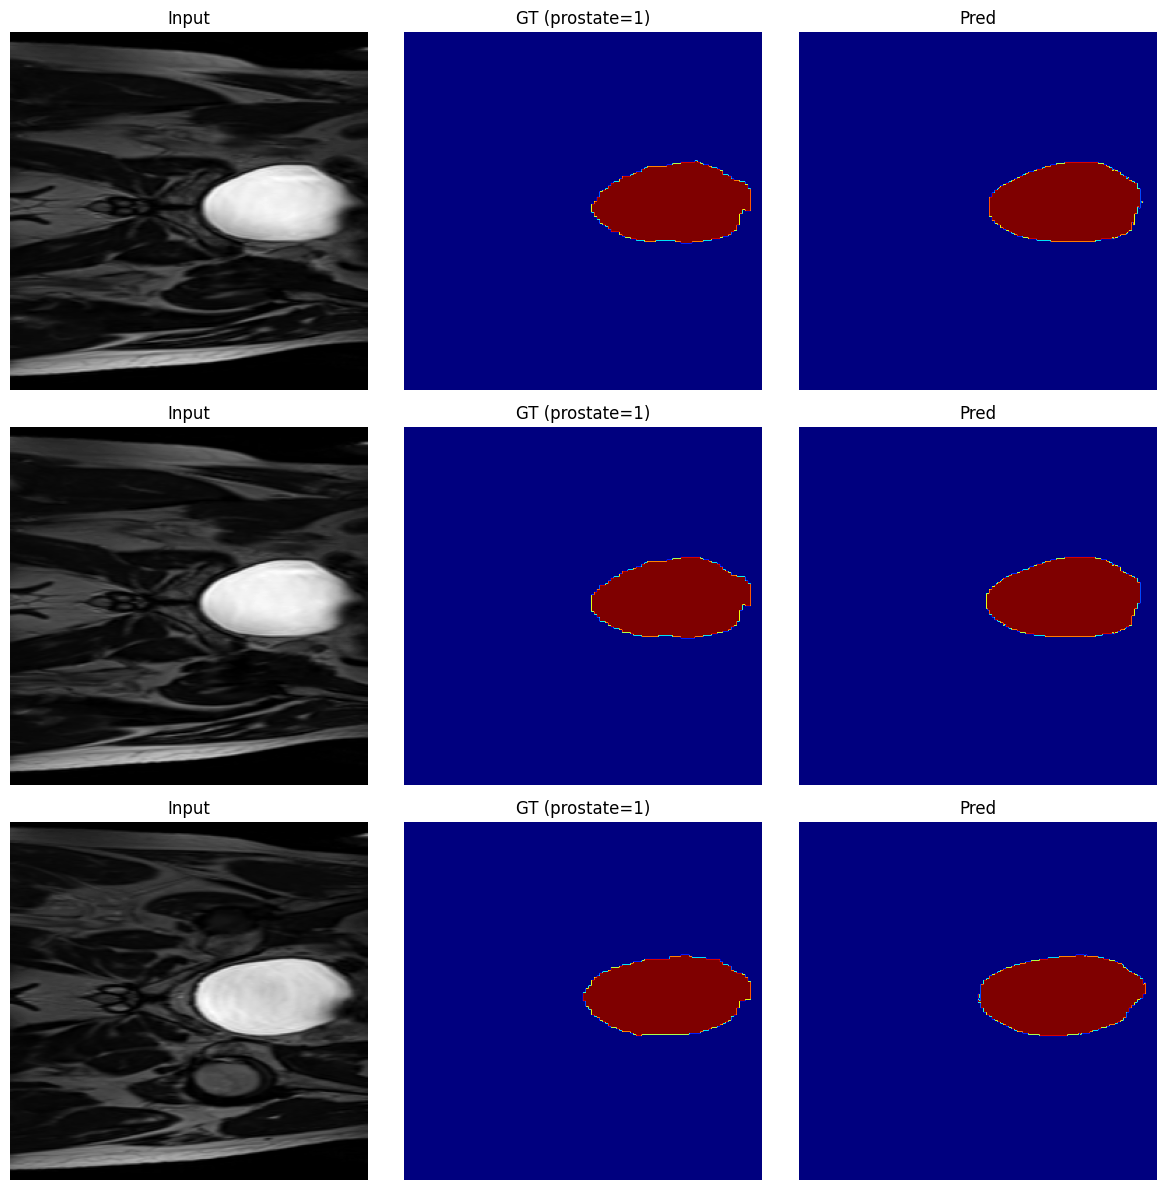

Done. Best checkpoint saved to models/unet2d_hipmri_best.pth


In [ ]:
# HipMRI 2D Prostate Segmentation with U-Net (PyTorch)
# =====================================================
# COMP3710 Task 2 — segment prostate on HipMRI 2D slices with Dice >= 0.75 (test)
# This notebook is self-contained and includes:
#  - Robust image/mask pairing (handles 'case_' vs 'seg_' and regex on trailing slice id)
#  - Binary mapping to prostate vs background (DEF_PROSTATE_LABEL = 3)
#  - Train/val/test loops with Dice metric
#  - Best-checkpoint saving and sample visualisation
#
# Notes:
#  - Keep your dataset OUTSIDE the repo. Point `data_root` to your local path.
#  - Run your separate `decompress_data.py` once to create .nii files from .nii.gz archives.

# --- 0. Imports & Config ---
import os, glob, re, math, time
from pathlib import Path
from typing import Tuple

import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# If you ever need more explicit CUDA errors, uncomment this:
# import os; os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# --- 1. Paths (EDIT THIS TO YOUR MACHINE) ---
# Keep data outside your repo; do NOT commit datasets.
data_root = r"C:\Users\User\Desktop\Final project comp3710\keras_slices_data"
img_train_dir = os.path.join(data_root, 'keras_slices_train')
seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')
img_val_dir   = os.path.join(data_root, 'keras_slices_validate')
seg_val_dir   = os.path.join(data_root, 'keras_slices_seg_validate')
img_test_dir  = os.path.join(data_root, 'keras_slices_test')
seg_test_dir  = os.path.join(data_root, 'keras_slices_seg_test')

# Sanity check exists (warn only)
for p in [img_train_dir, seg_train_dir, img_val_dir, seg_val_dir, img_test_dir, seg_test_dir]:
    if not os.path.isdir(p):
        print('[WARN] Missing dir:', p)

# --- 2. Utilities ---
DEF_PROSTATE_LABEL = 3  # from your sanity check: labels were [0,1,2,3], prostate=3

# capture trailing pattern like: 004_week_0_slice_0
_TRAIL_PAT = re.compile(r'(\d+_week_\d+_slice_\d+)$')

def _slice_key_from_stem(stem: str) -> str:
    """
    Returns canonical key for pairing image/seg.
    Prefers trailing '004_week_0_slice_0' pattern; falls back to dropping 'case_'/'seg_' prefixes.
    """
    m = _TRAIL_PAT.search(stem)
    if m:
        return m.group(1)
    if stem.startswith('case_'):
        return stem[len('case_'):]
    if stem.startswith('seg_'):
        return stem[len('seg_'):]
    return stem

def _slice_key(p: Path) -> str:
    return _slice_key_from_stem(p.stem)

# Optional: list unique labels quickly
def scan_unique_labels(seg_dir: str, k: int = 10):
    pats = sorted(glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True))[:k]
    uniqs = set()
    for p in pats:
        a = nib.load(p).get_fdata()
        uniqs.update(np.unique(np.rint(a)).astype(int).tolist())
    print('[DEBUG] Unique label ids (first', k, 'masks):', sorted(list(uniqs)))

# --- 3. Dataset (with fixed-size resizing) ---
class HipMRIDataset(Dataset):
    def __init__(self, img_dir: str, seg_dir: str, prostate_label: int = DEF_PROSTATE_LABEL,
                 binary: bool = True, target_size=(256, 256)):
        self.target_size = target_size  # (H, W)
        img_paths = sorted([Path(p) for p in glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True)])
        seg_paths = sorted([Path(p) for p in glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True)])

        if len(img_paths) == 0 or len(seg_paths) == 0:
            raise RuntimeError(f"No .nii files found.\n  img_dir={img_dir}\n  seg_dir={seg_dir}")

        img_map = { _slice_key(p): p for p in img_paths }
        seg_map = { _slice_key(p): p for p in seg_paths }
        common = sorted(set(img_map.keys()) & set(seg_map.keys()))

        if len(common) == 0:
            img_only = sorted(list(set(img_map.keys()) - set(seg_map.keys())))[:10]
            seg_only = sorted(list(set(seg_map.keys()) - set(img_map.keys())))[:10]
            raise RuntimeError(
                "No matching image/seg pairs found.\n"
                f"  Only-in-IMG (first 10): {img_only}\n"
                f"  Only-in-SEG (first 10): {seg_only}\n"
            )

        if len(img_paths) != len(seg_paths):
            print(f"[WARN] images={len(img_paths)} segs={len(seg_paths)}; using matched pairs={len(common)}")

        self.pairs = [(img_map[k], seg_map[k]) for k in common]
        self.prostate_label = prostate_label
        self.binary = binary

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int):
        img_path, seg_path = self.pairs[idx]
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        seg = nib.load(str(seg_path)).get_fdata()
        seg = np.rint(seg).astype(np.int64)   # ensure integer mask

        # Normalise image (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Binary mapping: prostate vs background
        if self.binary:
            seg = (seg == self.prostate_label).astype(np.int64)  # {0,1}

        # To tensors
        img_t = torch.from_numpy(img[None, ...]).float()  # (1,H,W)
        seg_t = torch.from_numpy(seg[None, ...]).float()  # (1,H,W) as float for interpolate

        # --- Resize to a fixed size (e.g., 256x256) ---
        # UNet downsamples 3 times (factor 8), so 256 is safe (divisible by 8).
        H, W = self.target_size
        img_t = F.interpolate(img_t.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False).squeeze(0)
        seg_t = F.interpolate(seg_t.unsqueeze(0), size=(H, W), mode='nearest').squeeze(0)

        # Back to expected shapes/dtypes
        seg_t = seg_t.squeeze(0).long()       # (H,W) long in {0,1}
        # img_t already (1,H,W) float

        return img_t, seg_t


# --- 4. Model (U-Net 2D) ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, n_classes=2, base=64):
        super().__init__()
        self.inc   = DoubleConv(1, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base,   base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))
        self.up1   = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv1 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up3   = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.conv3 = DoubleConv(base*2, base)
        self.outc  = nn.Conv2d(base, n_classes, 1)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x  = self.up1(x4)
        x  = torch.cat([x, x3], dim=1)
        x  = self.conv1(x)
        x  = self.up2(x)
        x  = torch.cat([x, x2], dim=1)
        x  = self.conv2(x)
        x  = self.up3(x)
        x  = torch.cat([x, x1], dim=1)
        x  = self.conv3(x)
        return self.outc(x)

# --- 5. Metrics ---
def dice_binary_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> float:
    """Binary Dice on foreground class. logits: (N,2,H,W), target: (N,H,W) in {0,1}."""
    probs = torch.softmax(logits, dim=1)[:, 1]   # foreground prob
    pred  = (probs > 0.5).long()
    target = target.long()
    intersection = (pred & target).sum(dim=(1,2)).float()
    union       = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2*intersection + eps) / (union + eps)).mean().item()

@torch.no_grad()
def evaluate_dice(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for imgs, segs in loader:
        imgs, segs = imgs.to(device), segs.to(device)
        logits = model(imgs)
        total += dice_binary_from_logits(logits, segs)
    return total / max(1, len(loader))

# --- 6. DataLoaders ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir, prostate_label=DEF_PROSTATE_LABEL, binary=True)
val_dataset   = HipMRIDataset(img_val_dir,   seg_val_dir,   prostate_label=DEF_PROSTATE_LABEL, binary=True)
test_dataset  = HipMRIDataset(img_test_dir,  seg_test_dir,  prostate_label=DEF_PROSTATE_LABEL, binary=True)

# On Windows keep num_workers=0 to avoid file handle issues
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
# Peek one sample
img0, seg0 = train_dataset[0]
print("Sample shapes:", tuple(img0.shape), tuple(seg0.shape), "labels min..max:", int(seg0.min()), int(seg0.max()))

# --- 7. Train ---
model = UNet2D(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()            # targets in {0,1}
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
# Optional speed-up on CUDA
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

EPOCHS = 20
best_val_dice = -1.0
os.makedirs('models', exist_ok=True)
best_ckpt = 'models/unet2d_hipmri_best.pth'

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    for imgs, segs in train_loader:
        imgs, segs = imgs.to(device), segs.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, segs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_dice += dice_binary_from_logits(logits, segs)

    train_loss = running_loss / max(1, len(train_loader))
    train_dice = running_dice / max(1, len(train_loader))
    val_dice   = evaluate_dice(model, val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_ckpt)

    print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss {train_loss:.4f} | Train Dice {train_dice:.4f} | Val Dice {val_dice:.4f} | Best {best_val_dice:.4f}")

print('Training complete. Best Val Dice:', best_val_dice)

# --- 8. Test evaluation (load best) ---
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.to(device)

test_dice = evaluate_dice(model, test_loader)
print(f"TEST Dice (prostate): {test_dice:.4f}")

# --- 9. Visualisation of a few predictions ---
@torch.no_grad()
def show_samples(model, dataset, k=3):
    model.eval()
    plt.figure(figsize=(12, 4*k))
    for i in range(k):
        img, seg = dataset[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).cpu().squeeze()
        ax1 = plt.subplot(k, 3, 3*i+1); ax1.imshow(img.squeeze().numpy(), cmap='gray'); ax1.set_title('Input'); ax1.axis('off')
        ax2 = plt.subplot(k, 3, 3*i+2); ax2.imshow(seg.numpy(), cmap='jet');         ax2.set_title('GT (prostate=1)'); ax2.axis('off')
        ax3 = plt.subplot(k, 3, 3*i+3); ax3.imshow(pred.numpy(), cmap='jet');        ax3.set_title('Pred'); ax3.axis('off')
    plt.tight_layout(); plt.show()

show_samples(model, test_dataset, k=3)


In [ ]:

print('Done. Best checkpoint saved to', best_ckpt)


In [3]:

torch.save(model, "models/unet2d_hipmri_full.pth")
